In [2]:
from models.esm_backbone import ESM
from models.linear_regression import train_model
from data.dataset import ProteinDataset
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np

In [3]:
    
data_dir=Path('./data')
variants = pd.read_csv(data_dir/f'{'train'}.csv')
Sequences = pd.read_csv(data_dir/'Sequences.csv', index_col='ensp')

In [6]:
train_dataset = ProteinDataset(split="train", variants=variants, Sequences=Sequences)
loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
model = ESM().to('cuda')
rows = []
for i, (protein, accession, score) in tqdm(enumerate(loader), total=500):
    forward = model.forward(protein)
    row = (accession[0], forward[0].tolist(), score[0].item())
    rows.append(row)
    if i == 500:
        break

100%|██████████| 500/500 [01:17<00:00,  6.42it/s]


In [15]:
import ast
if Path("esm_features.csv").exists():
    features_df = pd.read_csv("esm_features.csv")
    features_df['features'] = features_df['features'].apply(ast.literal_eval)
    
else:
    features_df = pd.DataFrame(rows, columns=['accession', 'features', 'score'])
X = np.stack(features_df["features"].to_numpy())

import umap

reducer = umap.UMAP(n_components=2, metric='cosine')
X_umap = reducer.fit_transform(X)

features_df["umap1"] = X_umap[:, 0]
features_df["umap2"] = X_umap[:, 1]

features_df.to_csv('esm_features.csv', index=False)


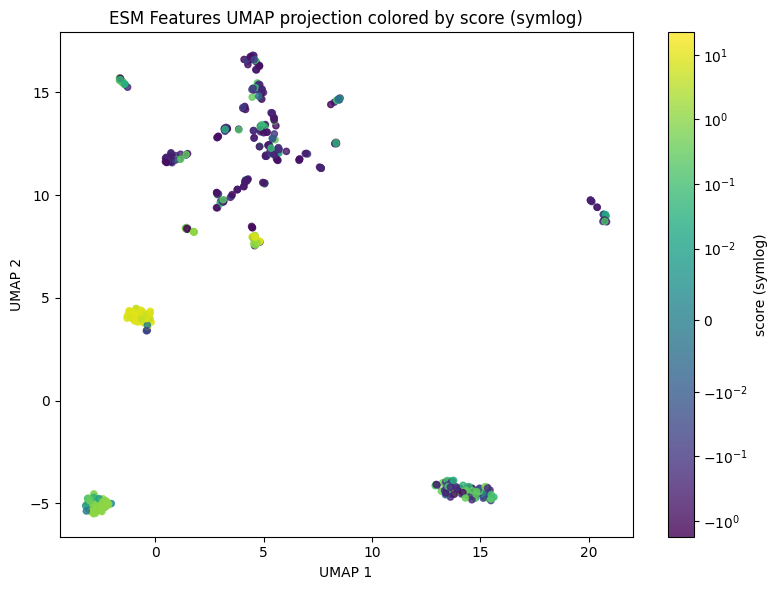

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

scores = features_df["score"].values

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    features_df["umap1"],
    features_df["umap2"],
    c=scores,
    cmap="viridis",
    s=20,
    alpha=0.8,
    norm=SymLogNorm(linthresh=1e-2, linscale=1.0, vmin=scores.min(), vmax=scores.max())
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("ESM Features UMAP projection colored by score (symlog)")
plt.colorbar(sc, label="score (symlog)")
plt.tight_layout()
plt.show()
